<a href="https://colab.research.google.com/github/Claudiopj88/Atividades_ANN/blob/main/Atividade_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

O conjunto de dados "Steel Industry Energy Consumption" registra o consumo de energia elétrica de uma fábrica de bobinas e placas de aço.  
Os dados foram coletados em intervalos de 15 minutos no período de 1 ano e estão categorizados conforme abaixo:  
-Date  
-Usage_kWh  
-Lagging_Current_Reactive.Power_kVarh  
-Leading_Current_Reactive_Power_kVarh  
-CO2(tCO2)  
-Lagging_Current_Power_Factor  
-Leading_Current_Power_Factor  
-NSM  
-Day_of_week  
-Load_Type  

Para o desenvolvimento desta atividade foram utilizadas 6 variáveis para previsão do consumo de energia "Usage_kWh".  

Link do Dataset:  
https://archive.ics.uci.edu/dataset/851/steel+industry+energy+consumption




In [ ]:
!wget https://archive.ics.uci.edu/static/public/851/steel+industry+energy+consumption.zip
!unzip -q "steel+industry+energy+consumption.zip"
!rm "steel+industry+energy+consumption.zip"

--2026-06-27 13:49:07--  https://archive.ics.uci.edu/static/public/851/steel+industry+energy+consumption.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘steel+industry+energy+consumption.zip’

steel+industry+ener     [   <=>              ] 470.68K   857KB/s    in 0.5s    

2026-06-27 13:49:08 (857 KB/s) - ‘steel+industry+energy+consumption.zip’ saved [481973]



In [ ]:
import pandas as pd

df = pd.read_csv('Steel_industry_data.csv')
print(f"Dimensões do Dataset: {df.shape}")
df[30000:30004]

Dimensões do Dataset: (35040, 11)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
30000,09/11/2018 12:15,5.15,0.0,18.04,0.0,100.0,27.45,44100,Weekday,Friday,Medium_Load
30001,09/11/2018 12:30,4.82,0.0,18.07,0.0,100.0,25.77,45000,Weekday,Friday,Medium_Load
30002,09/11/2018 12:45,4.97,0.0,15.88,0.0,100.0,29.87,45900,Weekday,Friday,Medium_Load
30003,09/11/2018 13:00,4.72,0.0,16.42,0.0,100.0,27.63,46800,Weekday,Friday,Medium_Load


In [ ]:
import os
from pprint import pprint
fname = os.path.join('Steel_industry_data.csv')

with open(fname) as f:
    data = f.read()
lines = data.split('\n')
header = lines[0].split(',')
lines = lines[1:]
pprint(header)
print(len(lines))

['\ufeffdate',
 'Usage_kWh',
 'Lagging_Current_Reactive.Power_kVarh',
 'Leading_Current_Reactive_Power_kVarh',
 'CO2(tCO2)',
 'Lagging_Current_Power_Factor',
 'Leading_Current_Power_Factor',
 'NSM',
 'WeekStatus',
 'Day_of_week',
 'Load_Type']
35041


In [ ]:
import numpy as np
usage_kwh = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), 7))
for i, line in enumerate(lines):
    if ',' not in line:
        continue
    values = [float(x) for x in line.split(',')[1:8]]
    usage_kwh[i] = values[0]
    raw_data[i, :] = values[:]


raw_data.shape

(35040, 7)

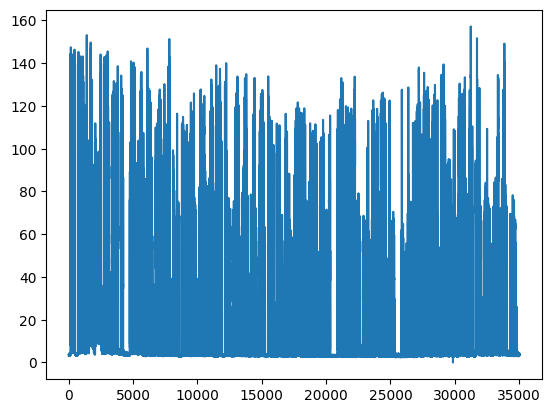

In [ ]:
from matplotlib import pyplot as plt
plt.plot(range(len(usage_kwh)), usage_kwh)
plt.show()


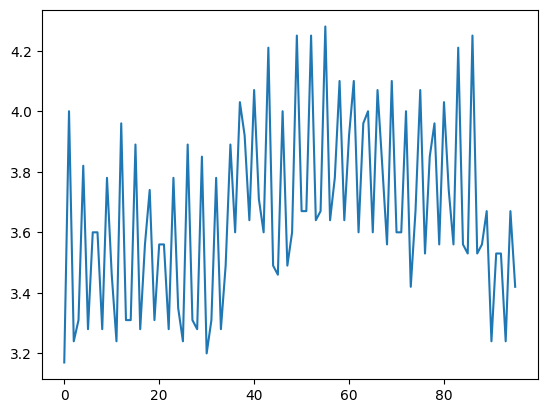

In [ ]:
um_dia = 4*24*1
plt.plot(range(um_dia), usage_kwh[:um_dia])
plt.show()

In [ ]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print('num_train_samples:', num_train_samples)
print('num_val_samples:', num_val_samples)
print('num_test_samples:', num_test_samples)

num_train_samples: 17520
num_val_samples: 8760
num_test_samples: 8760


In [ ]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

print(f"mean: {mean[0]}")
print(f"std: {std[0]}")

mean: 29.822371004566588
std: 35.29521666023423


In [ ]:
from tensorflow import keras

sampling_rate = 4 # 1 ponto/hora (4 × 15min = 1h)
sequence_length = 168 # 168 horas = 1 semana de histórico
delay = sampling_rate * (sequence_length + 24 - 1) # prever 24h à frente
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=usage_kwh[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples
)
val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=usage_kwh[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples+num_val_samples
)
test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=usage_kwh[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples+num_val_samples
)





In [ ]:
for samples, targets in train_dataset:
    print(f"samples shape: {samples.shape}")
    print(f"targets shape: {targets.shape}")
    break

samples shape: (256, 168, 7)
targets shape: (256,)


In [ ]:
def evaluate_naive_method(dataset):
    total_abs_err = 0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 0] * std[0] + mean[0]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen
print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 13.36
Test MAE: 15.87


In [ ]:
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('Steel_industry_data.keras', save_best_only=True)
]
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)
model = keras.models.load_model('Steel_industry_data.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 903.3654 - mae: 19.3250 - val_loss: 433.2025 - val_mae: 13.8802
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 519.1141 - mae: 15.2224 - val_loss: 401.3756 - val_mae: 12.7342
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 467.4004 - mae: 14.2591 - val_loss: 395.2796 - val_mae: 12.3286
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 439.2658 - mae: 13.7175 - val_loss: 395.7175 - val_mae: 12.3062
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 420.4901 - mae: 13.3854 - val_loss: 395.4416 - val_mae: 12.3078
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 403.3973 - mae: 13.1201 - val_loss: 400.3974 - val_mae: 12.2878
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 389.4044 - mae: 12.8646 - val_loss: 398.4249 - val_mae: 12.4268
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 376.5189 - mae: 12.6525 - val_loss: 404.5969 - val_mae: 12.6011
Epoch 9/10
66/66

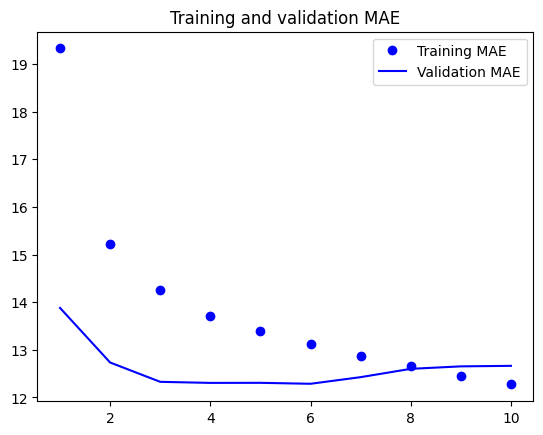

In [ ]:
import matplotlib.pyplot as plt
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation='relu')(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation='relu')(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation='relu')(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('Steel_industry_data.keras', save_best_only=True)
]
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks
)
model = keras.models.load_model('Steel_industry_data.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - loss: 1393.1980 - mae: 28.6567 - val_loss: 905.0690 - val_mae: 25.8960
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 1143.5884 - mae: 28.7552 - val_loss: 915.7493 - val_mae: 25.4441
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 1122.9543 - mae: 28.3631 - val_loss: 925.1658 - val_mae: 25.4631
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 1110.7175 - mae: 28.1530 - val_loss: 930.0864 - val_mae: 25.5004
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 1100.9596 - mae: 27.9611 - val_loss: 935.6796 - val_mae: 25.7414
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 1091.9956 - mae: 27.8041 - val_loss: 908.3222 - val_mae: 24.0706
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 1084.3352 - mae: 27.6361 - val_loss: 903.2896 - val_mae: 23.4958
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 1070.4348 - mae: 27.3511 - val_loss: 918.4860 - val_mae: 25.5399
Epoch 9/

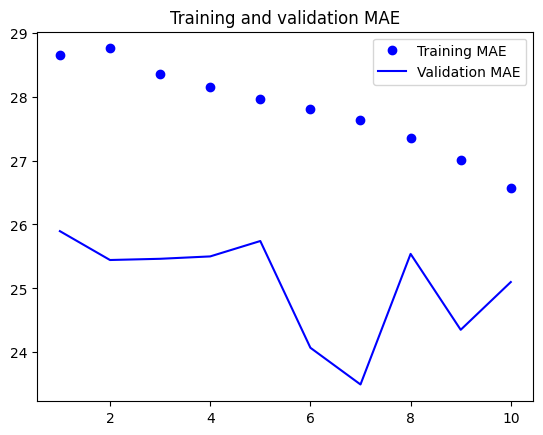

In [ ]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("Steel_industry_data_LSTM.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("Steel_industry_data_LSTM.keras")
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 2014.9962 - mae: 28.4465 - val_loss: 1282.0938 - val_mae: 20.1231
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 1865.5436 - mae: 26.2555 - val_loss: 1209.1045 - val_mae: 20.1436
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 1782.2587 - mae: 26.0573 - val_loss: 1157.7216 - val_mae: 20.5248
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 1719.1566 - mae: 26.1879 - val_loss: 1117.7897 - val_mae: 20.9179
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 1666.3652 - mae: 26.3584 - val_loss: 1083.3568 - val_mae: 21.2101
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 1617.9257 - mae: 26.3514 - val_loss: 1047.8999 - val_mae: 20.9881
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 1570.1636 - mae: 25.9366 - val_loss: 1013.1213 - val_mae: 20.3869
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 1523.7109 - mae: 25.5602 - val_loss: 982.0081 - val_mae: 20.1855
E

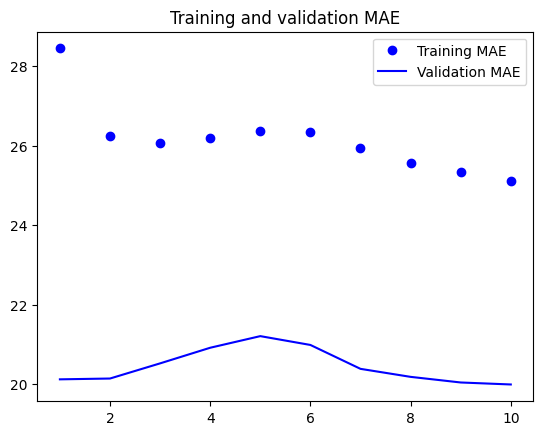

In [ ]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("Steel_industry_data_LSTM_Dropout.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("Steel_industry_data_LSTM_Dropout.keras")
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 1969.6355 - mae: 27.7708 - val_loss: 1239.5635 - val_mae: 20.1157
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 1807.1906 - mae: 26.2706 - val_loss: 1166.5531 - val_mae: 20.4576
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 1730.1893 - mae: 26.2775 - val_loss: 1119.9146 - val_mae: 20.8679
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 1671.2838 - mae: 26.3871 - val_loss: 1083.9589 - val_mae: 21.2442
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 1625.5754 - mae: 26.5305 - val_loss: 1051.8656 - val_mae: 21.4504
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 1578.4418 - mae: 26.3297 - val_loss: 1015.2909 - val_mae: 20.7131
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 1531.1343 - mae: 25.7192 - val_loss: 983.9156 - val_mae: 20.0556
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 1489.0875 - mae: 25.3490 - val_loss: 954.4505 - val_mae: 19.9215
Ep

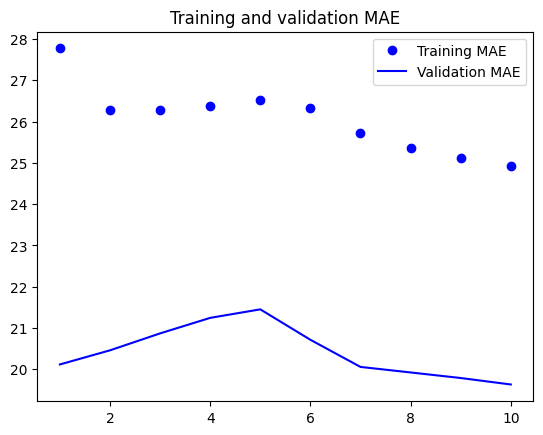

In [ ]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("Steel_industry_data_gru.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("Steel_industry_data_gru.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - loss: 1811.8121 - mae: 27.1946 - val_loss: 1063.5637 - val_mae: 21.5260
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 1576.4844 - mae: 26.5976 - val_loss: 996.4609 - val_mae: 21.0288
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - loss: 1480.8890 - mae: 25.3594 - val_loss: 929.9444 - val_mae: 19.7104
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 1398.3376 - mae: 24.6777 - val_loss: 871.8820 - val_mae: 19.0438
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - loss: 1321.3435 - mae: 24.0838 - val_loss: 821.8578 - val_mae: 18.5469
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 1254.5020 - mae: 23.6207 - val_loss: 777.3907 - val_mae: 18.2698
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - loss: 1191.9420 - mae: 23.1586 - val_loss: 732.6707 - val_mae: 17.6077
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - loss: 1136.6117 - mae: 22.6808 - val_loss: 697.0428 - val_mae: 17.1502
Epoch 9/10
66/6

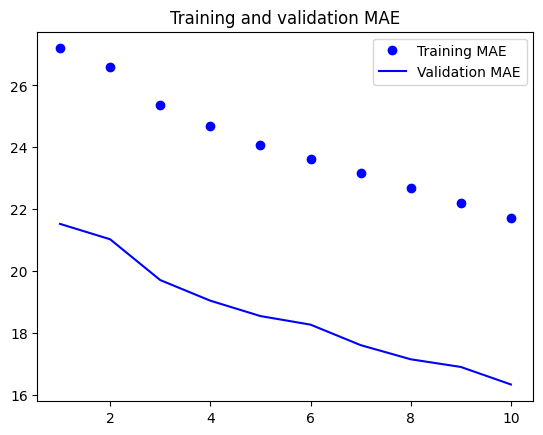

In [ ]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [keras.callbacks.ModelCheckpoint("Steel_industry_data_lstm.keras", save_best_only=True)]

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("Steel_industry_data_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 1949.3325 - mae: 27.7805 - val_loss: 1169.9297 - val_mae: 19.9823
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 1673.4150 - mae: 25.9337 - val_loss: 1049.7020 - val_mae: 20.8980
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 1542.3518 - mae: 26.2936 - val_loss: 977.9634 - val_mae: 21.4109
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 1449.0953 - mae: 26.2145 - val_loss: 914.1714 - val_mae: 20.9091
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 1367.2690 - mae: 25.5012 - val_loss: 854.7272 - val_mae: 19.8862
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 1291.1559 - mae: 24.7381 - val_loss: 805.0687 - val_mae: 19.2867
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 1221.8733 - mae: 24.1303 - val_loss: 761.6573 - val_mae: 18.8396
Epoch 8/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 1158.4858 - mae: 23.5813 - val_loss: 724.7028 - val_mae: 18.5722
Epoch 

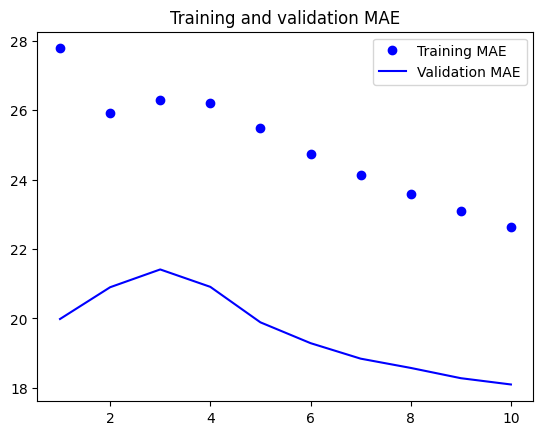

In [ ]:
loss = history.history['mae']
val_loss = history.history['val_mae']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training MAE')
plt.plot(epochs, val_loss, 'b', label='Validation MAE')
plt.title('Training and validation MAE')
plt.legend()
plt.show()